In [2]:
import sys, os
PROJECT_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd())=='notebooks' else os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)
os.chdir(PROJECT_ROOT)


Project root: /Users/tony/Documents/CSC790_001_XAI_Papers/Explaining-Autonomous-Vehicle-Decisions


In [3]:
from src.utils.config import load_config
from src.envs.highway_env import make_env
from src.agents.dqn_agent import DQNAgent
from src.training.train_highway import evaluate
import numpy as np
from pathlib import Path
import time

In [5]:
cfg = load_config("configs/config.yaml")

env = make_env(cfg)
obs_space = env.observation_space
action_space = env.action_space

agent = DQNAgent(cfg, obs_space, action_space)

agent_cfg = getattr(cfg, "agent", {})
total_timesteps = int(getattr(agent_cfg, "total_timesteps", 20000))

state, _ = env.reset()
episode_return = 0.0
episode_len = 0
episode = 0

rewards_log = []
start_time = time.time()

for t in range(1, total_timesteps + 1):
    action = agent.act(state)
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    agent.remember(state, action, reward, next_state, done)
    loss, mean_q = agent.learn()

    episode_return += float(reward)
    episode_len += 1
    state = next_state

    if done:
        rewards_log.append(
            {"timestep": t, "episode": episode,
             "return": episode_return, "length": episode_len}
        )
        state, _ = env.reset()
        episode_return = 0.0
        episode_len = 0
        episode += 1

    if t % 2000 == 0:
        eval_stats = evaluate(env, agent, n_episodes=3)
        elapsed = time.time() - start_time
        print(f"Step {t}: eval_return={eval_stats['avg_return']:.2f}, "
              f"len={eval_stats['avg_length']:.1f}, time={elapsed/60:.1f} min")

print("Done training")

Step 2000: eval_return=3.98, len=5.0, time=19.8 min
Step 4000: eval_return=10.06, len=11.3, time=39.8 min
Step 6000: eval_return=29.64, len=40.0, time=196.9 min
Step 8000: eval_return=32.91, len=40.0, time=1361.0 min
Step 10000: eval_return=29.49, len=40.0, time=1401.0 min
Step 12000: eval_return=33.69, len=40.0, time=1434.1 min
Step 14000: eval_return=30.40, len=40.0, time=2343.0 min
Step 16000: eval_return=28.23, len=40.0, time=2397.0 min
Step 18000: eval_return=27.65, len=37.7, time=2418.1 min
Step 20000: eval_return=29.56, len=36.3, time=2545.3 min
Done training


In [6]:
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True, parents=True)

np.save(out_dir / "highway_rewards.npy", rewards_log, allow_pickle=True)
print("Saved rewards log.")

Saved rewards log.


In [7]:
from pathlib import Path

out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)

ckpt_path = out_dir / "dqn_highway_final.pt"
agent.save(str(ckpt_path))
print("Saved agent to", ckpt_path)
agent = DQNAgent(cfg, obs_space, action_space)
agent.load("outputs/dqn_highway_final.pt")

Saved agent to outputs/dqn_highway_final.pt


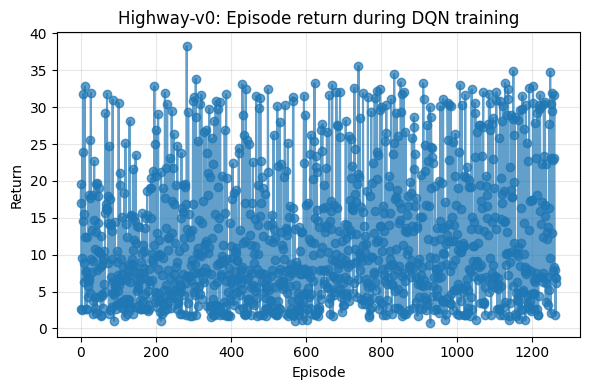

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

rewards_path = Path("outputs/highway_rewards.npy")
rewards_log = np.load(rewards_path, allow_pickle=True).tolist()

episodes = [r["episode"] for r in rewards_log]
returns = [r["return"] for r in rewards_log]

plt.figure(figsize=(6, 4))
plt.plot(episodes, returns, marker="o", alpha=0.7)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Highway-v0: Episode return during DQN training")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
from src.utils.config import load_config
from src.envs.highway_env import make_env
from src.agents.dqn_agent import DQNAgent
import torch
import numpy as np

cfg = load_config("configs/config.yaml")
env = make_env(cfg)  # make sure environment.render is false for no pygame window
obs_space = env.observation_space
action_space = env.action_space

agent = DQNAgent(cfg, obs_space, action_space)
agent.load("outputs/dqn_highway_final.pt")  # path you used when saving

frames = []
actions = []
q_values_list = []

state, _ = env.reset()
done = False

while not done:
    state_t = agent._state_to_tensor(state)
    with torch.no_grad():
        q_vals = agent.q_net(state_t).cpu().numpy()[0]
    action = int(q_vals.argmax())

    actions.append(action)
    q_values_list.append(q_vals)

    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    state = obs

    frame = env.render()  # returns an RGB array (since render_mode='rgb_array')
    frames.append(frame)

len(frames), len(actions)

(2, 2)

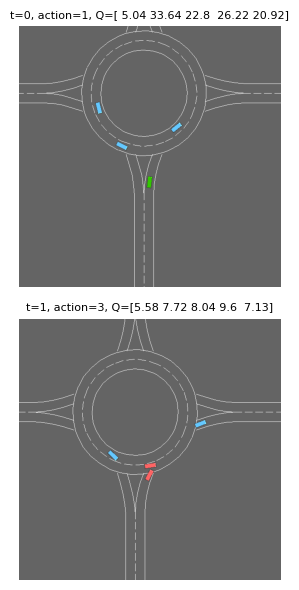

In [10]:
import matplotlib.pyplot as plt

n_show = min(6, len(frames))
indices = np.linspace(0, len(frames) - 1, n_show, dtype=int)

fig, axes = plt.subplots(2, n_show // 2, figsize=(3 * (n_show // 2), 6))
axes = axes.flatten()

for ax, idx in zip(axes, indices):
    ax.imshow(frames[idx])
    a = actions[idx]
    q = q_values_list[idx]
    ax.set_title(f"t={idx}, action={a}, Q={np.round(q, 2)}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Hybrid XAI: Action Explanations

The following cell runs the trained agent for one episode, computes SHAP values for the decisions, and generates a dashboard video overlaying the feature importance on the simulation frames.

In [ ]:
# Hybrid XAI: Generate Explanations with SHAP
from src.xai.shap_lime import explain_with_shap
from src.visualization.dashboard import render_episode_overview
import torch
import numpy as np
from IPython.display import Video

# Ensure agent is loaded (if running this cell independently after training)
if not hasattr(agent, 'q_net'):
    # Re-initialize if needed (assuming cfg, obs_space, action_space exist from previous cells)
    # agent = DQNAgent(cfg, obs_space, action_space)
    agent.load("outputs/dqn_highway_final.pt")

print("Running episode for explanation...")
frames = []
actions = []
states = []

state, _ = env.reset()
done = False
truncated = False

while not (done or truncated):
    # Render frame (ensure env is in rgb_array mode or similar)
    frame = env.render()
    frames.append(frame)

    # Act
    action = agent.act(state, exploit=True)
    actions.append(action)
    states.append(state)

    # Step
    next_state, reward, done, truncated, _ = env.step(action)
    state = next_state

print(f"Episode finished. Steps: {len(frames)}")

# Compute SHAP
print("Computing SHAP values...")
states_tensor = torch.as_tensor(np.stack(states), dtype=torch.float32).to(agent.device)
states_flat = states_tensor.view(states_tensor.shape[0], -1)

# Background: Random 50 samples from the episode
bg_size = min(50, len(states))
background_indices = np.random.choice(len(states), bg_size, replace=False)
background_data = states_flat[background_indices]

# Compute SHAP values
s_vals, _ = explain_with_shap(agent.q_net, states_flat, background_data)

# Select SHAP values for the chosen actions
final_saliencies = []
for i, a in enumerate(actions):
    final_saliencies.append(s_vals[a][i])

# Feature names (Kinematics for highway-env)
feature_names = []
num_vehicles = states_flat.shape[1] // 5
for v in range(num_vehicles):
    feature_names.extend([f"V{v}_Pres", f"V{v}_x", f"V{v}_y", f"V{v}_vx", f"V{v}_vy"])

# Generate Video
out_video_path = "outputs/explanation_video.mp4"
render_episode_overview(frames, actions, final_saliencies, feature_names, out_video_path)

print(f"Video saved to {out_video_path}")
Video(out_video_path, embed=True, html_attributes="controls autoplay loop")


Running episode for explanation...
Episode finished. Steps: 11
Computing SHAP values...
Saved explanation video to outputs/explanation_video.mp4
Video saved to outputs/explanation_video.mp4


: 